In [1]:
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns

import os

from docutils.nodes import container
from matplotlib.pyplot import bar_label

'''
# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments'),
    ('order_items.csv','order_items')# Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Rajput@1412',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = 'D:/data science/data analysis/Ecommerce/archive'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)

    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)

    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)

    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()
'''

'\n# List of CSV files and their corresponding table names\ncsv_files = [\n    (\'customers.csv\', \'customers\'),\n    (\'orders.csv\', \'orders\'),\n    (\'sellers.csv\', \'sellers\'),\n    (\'products.csv\', \'products\'),\n    (\'geolocation.csv\', \'geolocation\'),\n    (\'payments.csv\', \'payments\'),\n    (\'order_items.csv\',\'order_items\')# Added payments.csv for specific handling\n]\n\n# Connect to the MySQL database\nconn = mysql.connector.connect(\n    host=\'localhost\',\n    user=\'root\',\n    password=\'Rajput@1412\',\n    database=\'ecommerce\'\n)\ncursor = conn.cursor()\n\n# Folder containing the CSV files\nfolder_path = \'D:/data science/data analysis/Ecommerce/archive\'\n\ndef get_sql_type(dtype):\n    if pd.api.types.is_integer_dtype(dtype):\n        return \'INT\'\n    elif pd.api.types.is_float_dtype(dtype):\n        return \'FLOAT\'\n    elif pd.api.types.is_bool_dtype(dtype):\n        return \'BOOLEAN\'\n    elif pd.api.types.is_datetime64_any_dtype(dtype):\n

In [2]:
db = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Rajput@1412',
    database='ecommerce'
)

cur=db.cursor()

**QUESTION:1** List all unique cities where customers are located.

In [23]:
query= """ select distinct(customer_city) from customers"""
cur.execute(query)
data=cur.fetchall()
data

[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

**QUESTION:2** Count the number of orders placed in 2017.

In [24]:
query= """ select  COUNT(ORDER_ID) from orders where YEAR(order_purchase_timestamp)=2017"""

cur.execute(query)
data=cur.fetchall()
data

[(90202,)]

**QUESTION:3** Find the total sales per category.

In [25]:
query= """ select p.product_category , round(sum(py.payment_value),2) from products p join order_items os on p.product_id=os.product_id join payments py on
 py.order_id=os.order_id group by p.product_category"""

cur.execute(query)
data=cur.fetchall()

df=pd.DataFrame(data)
df.sort_values(by=0,inplace=True)
df

,0,1
27,Agro Industria e Comercio,118730.61
51,Art,30992.93
53,Arts and Crafts,2326.17
21,Bags Accessories,187151.29
63,Blu Ray DVDs,7935.28
...,...,...
15,stationary store,317440.07
30,technical books,24915.44
2,telephony,486882.05
9,toys,619037.69


**QUESTION:4** Calculate the percentage of orders that were paid in installments.

In [26]:
query="""select round(sum(case when payment_installments >=1 then 1 else 0 end)/count(*) * 100,2) from  payments"""
cur.execute(query)
data=cur.fetchall()
data

[(Decimal('100.00'),)]

**QUESTION:5** Count the number of customers from each state.


In [27]:
query=""" select count(customer_id),customer_state from customers group by customer_state """


cur.execute(query)
data=cur.fetchall()
data

df=pd.DataFrame(data)
df.columns=['count','state']
df


,count,state
0,83492,SP
1,7274,SC
2,23270,MG
3,10090,PR
4,25704,RJ
5,10932,RS
6,1950,PA
7,4040,GO
8,4066,ES
9,6760,BA


**QUESTION : 6** Calculate the number of orders per month in 2018.

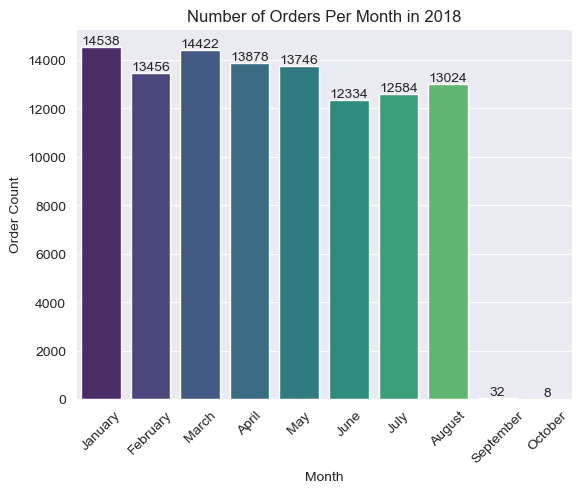

In [28]:
query = """
    SELECT COUNT(order_id) AS count,
           MONTHNAME(order_purchase_timestamp) AS month
    FROM orders
    WHERE YEAR(order_purchase_timestamp) = 2018
    GROUP BY month
    ORDER BY FIELD(month,
        'January', 'February', 'March', 'April', 'May', 'June',
        'July', 'August', 'September', 'October', 'November', 'December');
"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=['count', 'month'])

# Create a bar plot
ax = sns.barplot(x='month', y='count', data=df, palette='viridis')
plt.xticks(rotation=45)
plt.title("Number of Orders Per Month in 2018")
plt.xlabel("Month")
plt.ylabel("Order Count")


ax.bar_label(ax.containers[0])


plt.show()


**QUESTION :7** Find the average number of products per order, grouped by customer city.

In [29]:
query=""" with per_order_count as (select o.order_id,o.customer_id,count(oi.order_id) as oc from orders o join order_items oi on o.order_id=oi.order_id
group by o.customer_id,o.order_id)
select c.customer_city, round(avg(per_order_count.oc),2) from customers c join per_order_count on c.customer_id=per_order_count.customer_id group by c.customer_city"""

cur.execute(query)
data = cur.fetchall()
data

[('treze tilias', Decimal('2.55')),
 ('indaial', Decimal('2.23')),
 ('sao jose dos campos', Decimal('2.28')),
 ('sao paulo', Decimal('2.31')),
 ('porto alegre', Decimal('2.35')),
 ('santos', Decimal('2.32')),
 ('sao francisco do sul', Decimal('2.47')),
 ('sao vicente', Decimal('2.18')),
 ('joinville', Decimal('2.21')),
 ('sao vendelino', Decimal('2.00')),
 ('belo horizonte', Decimal('2.29')),
 ('bage', Decimal('2.10')),
 ('gravatai', Decimal('2.13')),
 ('sumare', Decimal('2.27')),
 ('rio de janeiro', Decimal('2.29')),
 ('navegantes', Decimal('2.32')),
 ('nova iguacu', Decimal('2.29')),
 ('chapada do norte', Decimal('2.00')),
 ('sao bernardo do campo', Decimal('2.28')),
 ('frederico westphalen', Decimal('2.14')),
 ('contagem', Decimal('2.29')),
 ('curitiba', Decimal('2.32')),
 ('guaranta', Decimal('2.00')),
 ('miracema', Decimal('2.11')),
 ('campo grande', Decimal('2.29')),
 ('sao jose', Decimal('2.36')),
 ('rodeio', Decimal('2.29')),
 ('barueri', Decimal('2.23')),
 ('urussanga', Decima

**QUESTION:8**  Calculate the percentage of total revenue contributed by each product category.

In [30]:
query=""" select p.product_category , round(sum(py.payment_value)/(select sum(payment_value) from payments)*100,2) from products p
join order_items oi on p.product_id=oi.product_id join payments py on py.order_id=oi.order_id group by p.product_category"""

cur.execute(query)
data = cur.fetchall()
data
df=pd.DataFrame(data)
df.columns=['category','percentage']
df.sort_values(by='percentage',ascending=False)

,category,percentage
4,bed table bath,10.70
12,HEALTH BEAUTY,10.35
6,computer accessories,9.90
1,Furniture Decoration,8.93
16,Watches present,8.93
...,...,...
53,Arts and Crafts,0.01
69,cds music dvds,0.01
72,PC Gamer,0.01
71,Fashion Children's Clothing,0.00


**QUESTION:9**  Identify the correlation between product price and the number of times a product has been purchased.


In [38]:
query=""" select p.product_category,count(oi.product_id),round(avg(oi.price),2) from products p join order_items oi on p.product_id=oi.product_id group by P.product_category"""

cur.execute(query)
data = cur.fetchall()
data
df=pd.DataFrame(data)
df.columns=['category','count','price']
df

,category,count,price
0,HEALTH BEAUTY,9670,130.16
1,sport leisure,8641,114.34
2,Cool Stuff,3796,167.36
3,computer accessories,7827,116.51
4,Watches present,5991,201.14
...,...,...,...
69,flowers,33,33.64
70,Kitchen portable and food coach,15,264.57
71,House Comfort 2,30,25.34
72,CITTE AND UPHACK FURNITURE,38,114.95


**QUESTION:10** 5. Calculate the total revenue generated by each seller, and rank them by revenue.


In [43]:
query="""select oi.seller_id, round(sum(py.payment_value),2) total, dense_rank() over(order by sum(payment_value) desc) as ranking  from order_items oi join payments py on oi.order_id=py.order_id group by oi.seller_id """

cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.columns=['seller_id','Revenue','Rank']
df

,seller_id,Revenue,Rank
0,7c67e1448b00f6e969d365cea6b010ab,507166.91,1
1,1025f0e2d44d7041d6cf58b6550e0bfa,308222.04,2
2,4a3ca9315b744ce9f8e9374361493884,301245.27,3
3,1f50f920176fa81dab994f9023523100,290253.42,4
4,53243585a1d6dc2643021fd1853d8905,284903.08,5
...,...,...,...
3090,ad14615bdd492b01b0d97922e87cb87f,19.21,3082
3091,702835e4b785b67a084280efca355756,18.56,3083
3092,4965a7002cca77301c82d3f91b82e1a9,16.36,3084
3093,77128dec4bec4878c37ab7d6169d6f26,15.22,3085


**QUESTION : 11** 2. Calculate the cumulative sales per month for each year.


In [3]:
query="""select customer_id, DATE(order_purchase_timestamp), payment,
round(avg(payment) over(partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row),2) as mov_avg
from
(select orders.customer_id, orders.order_purchase_timestamp,
payments.payment_value as payment
from payments join orders
on payments.order_id = orders.order_id) as a"""

cur.execute(query)
data=cur.fetchall()
data
df=pd.DataFrame(data)
df



,0,1,2,3
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14,114.74,114.74
1,00012a2ce6f8dcda20d059ce98491703,2017-11-14,114.74,114.74
2,000161a058600d5901f007fab4c27140,2017-07-16,67.41,67.41
3,000161a058600d5901f007fab4c27140,2017-07-16,67.41,67.41
4,0001fd6190edaaf884bcaf3d49edf079,2017-02-28,195.42,195.42
...,...,...,...,...
207767,ffff42319e9b2d713724ae527742af25,2018-06-13,214.13,214.13
207768,ffffa3172527f765de70084a7e53aae8,2017-09-02,45.50,45.50
207769,ffffa3172527f765de70084a7e53aae8,2017-09-02,45.50,45.50
207770,ffffe8b65bbe3087b653a978c870db99,2017-09-29,18.37,18.37


**QUESTION : 12**Calculate the year-over-year growth rate of total sales.


<Axes: xlabel='year', ylabel='total_sales'>

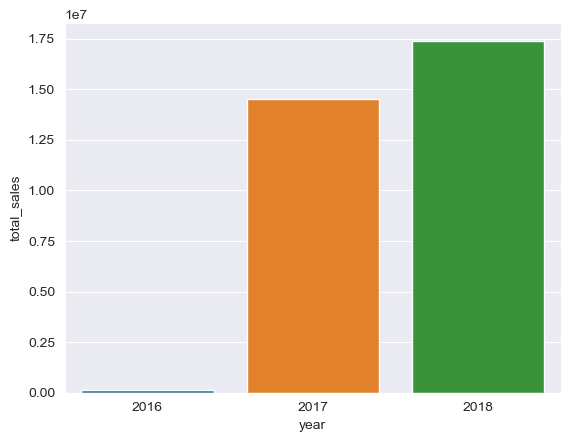

In [8]:
query=""" select year(o.order_purchase_timestamp),round(sum(p.payment_value),2) from orders o join payments p on o.order_id=p.order_id group by year(o.order_purchase_timestamp)
order by year(o.order_purchase_timestamp)
"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.columns=['year','total_sales']



**QUESTION:13** Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [3]:
query=""" with first_purchase as (select customer_id,min(order_purchase_timestamp) as first_date from orders group by customer_id),

 next_order AS (
    SELECT
        fp.customer_id,
        MIN(o.order_purchase_timestamp) AS second_date
    FROM first_purchase fp
    JOIN orders o
        ON fp.customer_id = o.customer_id
        where o.order_purchase_timestamp > fp.first_date and date_add(first_date,interval 6 month)
    GROUP BY fp.customer_id
)
select * from next_order
"""

cur.execute(query)
data=cur.fetchall()
data

[]